AND GATE SINGLE PERCEPTRON - RANDOM INITIALIZATION
 Initial Weights: W1=0.676, W2=0.710
 Initial Bias: b=0.491
 Equation: 0.676x1 + 0.710x2 + 0.491 > 0

PREDICTIONS
[0, 0] → Linear:  0.491 → Pred: 1 | Actual: 0
[0, 1] → Linear:  1.201 → Pred: 1 | Actual: 0
[1, 0] → Linear:  1.167 → Pred: 1 | Actual: 0
[1, 1] → Linear:  1.878 → Pred: 1 | Actual: 1


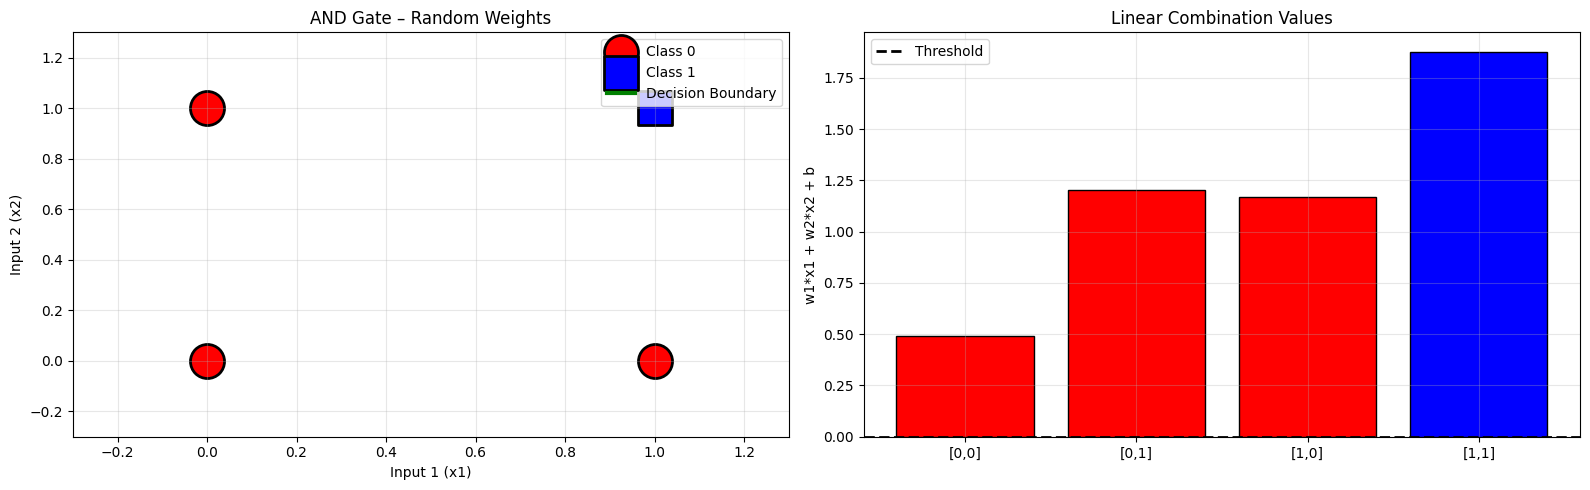


VERIFICATION:
[0, 0] → 0.491 → Class 1
[0, 1] → 1.201 → Class 1
[1, 0] → 1.167 → Class 1
[1, 1] → 1.878 → Class 1


In [1]:
# AND WITH RANDOM INITIALIZED
import numpy as np
import matplotlib.pyplot as plt

# Data for AND gate
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y = np.array([[0], [0], [0], [1]])

print("AND GATE SINGLE PERCEPTRON - RANDOM INITIALIZATION")
print("=" * 60)

# Random initialization
weights = np.random.uniform(-1, 1, size=(2, 1))
bias = np.random.uniform(-1, 1, size=(1, 1))

print(f" Initial Weights: W1={weights[0,0]:.3f}, W2={weights[1,0]:.3f}")
print(f" Initial Bias: b={bias[0,0]:.3f}")
print(f" Equation: {weights[0,0]:.3f}x1 + {weights[1,0]:.3f}x2 + {bias[0,0]:.3f} > 0")

def perceptron_predict(X, weights, bias):
    linear = np.dot(X, weights) + bias
    return (linear > 0).astype(int)

print("\nPREDICTIONS")
linear_values = np.dot(X, weights) + bias
predictions = perceptron_predict(X, weights, bias)

for i in range(len(X)):
    print(f"[{X[i,0]}, {X[i,1]}] → Linear: {linear_values[i,0]:6.3f} "
          f"→ Pred: {predictions[i,0]} | Actual: {y[i,0]}")

# Plot decision boundary and points
plt.figure(figsize=(16, 5))

plt.subplot(1, 2, 1)
plt.scatter(X[y.flatten() == 0, 0], X[y.flatten() == 0, 1],
            s=600, marker='o', edgecolors='black', linewidth=2,
            label='Class 0', color='red')
plt.scatter(X[y.flatten() == 1, 0], X[y.flatten() == 1, 1],
            s=600, marker='s', edgecolors='black', linewidth=2,
            label='Class 1', color='blue')

x1_range = np.linspace(-0.3, 1.3, 200)
w1, w2, b = weights[0,0], weights[1,0], bias[0,0]

if abs(w2) > 1e-6:
    x2_boundary = (-w1 * x1_range - b) / w2
    plt.plot(x1_range, x2_boundary, 'g-', linewidth=3, label='Decision Boundary')

plt.xlim(-0.3, 1.3)
plt.ylim(-0.3, 1.3)
plt.xlabel('Input 1 (x1)')
plt.ylabel('Input 2 (x2)')
plt.title('AND Gate – Random Weights')
plt.grid(True, alpha=0.3)
plt.legend()

# Bar plot of linear values
plt.subplot(1, 2, 2)
samples = ['[0,0]', '[0,1]', '[1,0]', '[1,1]']
colors = ['red' if y[i,0] == 0 else 'blue' for i in range(len(y))]

plt.bar(samples, linear_values.flatten(),
        color=colors, edgecolor='black', linewidth=1)
plt.axhline(y=0, color='black', linestyle='--', linewidth=2, label='Threshold')
plt.ylabel('w1*x1 + w2*x2 + b')
plt.title('Linear Combination Values')
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

print("\nVERIFICATION:")
for i in range(len(X)):
    z = w1 * X[i,0] + w2 * X[i,1] + b
    print(f"[{X[i,0]}, {X[i,1]}] → {z:.3f} → "
          f"{'Class 1' if z > 0 else 'Class 0'}")
